# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-16 19:35:59.609501: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-16 19:35:59.613577: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-16 19:35:59.681215: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-16 19:35:59.681290: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-16 19:35:59.681336: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [4]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"))

    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"))

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt"))

    y_train = y_train.astype(int) - 1
    y_test = y_test.astype(int) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))


## 5. Quick Inspection


In [5]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

# <-- Enter your code here <--#
unique_classes, counts = np.unique(y_train, return_counts=True)

summary_df = pd.DataFrame({
    "class_index": unique_classes,
    "class_name": [class_names[i] for i in unique_classes],
    "num_samples": counts
})

summary_df

,class_index,class_name,num_samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
def build_baseline_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),

        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model
baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
92/92 [==============================] - 2s 12ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 1s 8ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 1s 9ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 1s 8ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 1s 8ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 1s 8ms/step - loss: 0.0748 - accuracy: 0.9711 - val_loss: 0.2056 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 1s 8ms/step - loss: 0.0765 - accuracy: 0.9716 - val_loss: 0.1482 - val_accuracy: 0.9443
Epoch 8/40
92/92 [=

### Training Curves


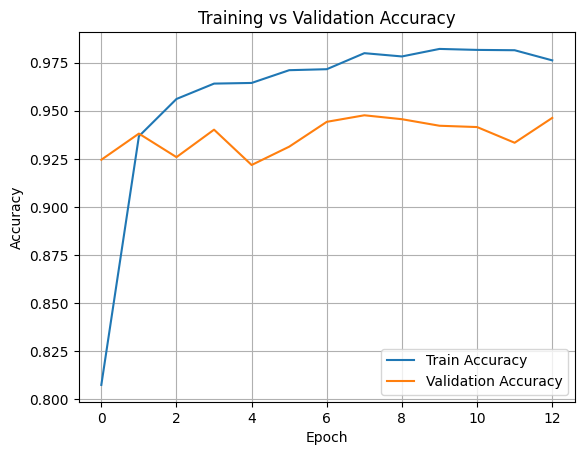

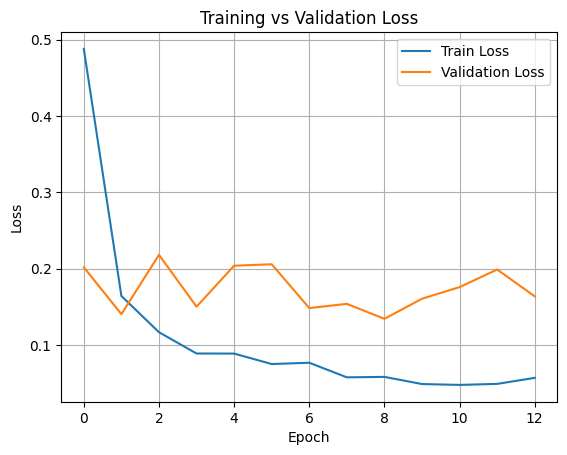

In [8]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 3ms/step
Test Accuracy: 0.9219545300305395

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.95      0.94      0.94       496
  WALKING_UPSTAIRS       0.95      0.90      0.92       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.98      0.80      0.88       491
          STANDING       0.81      0.98      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



<Figure size 800x800 with 0 Axes>

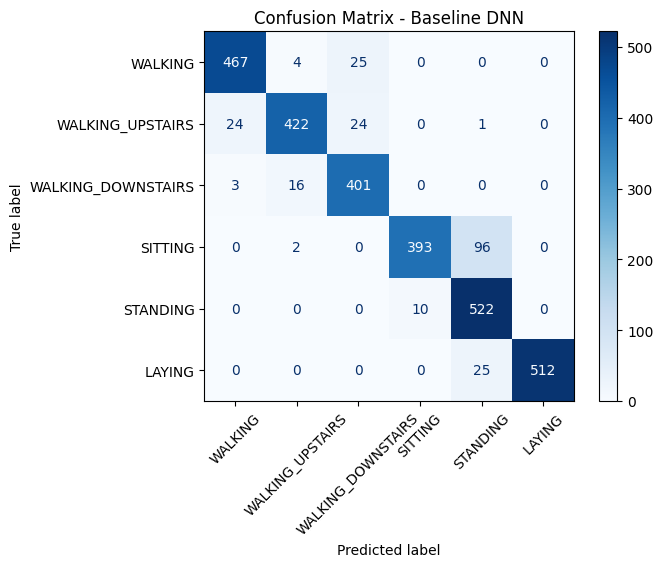

In [9]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
y_probs = baseline_model.predict(X_test)

y_pred = np.argmax(y_probs, axis=1)

test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(8, 8))
disp.plot(xticks_rotation=45, cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Baseline DNN")
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [10]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    # <-- Enter your code here <--#
    for i in range(300):
        sample = X_train[i].astype(np.float32)
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_details["dtype"] == np.int8 or input_details["dtype"] == np.uint8:
            x = x / input_scale + input_zero_point
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        # <-- Enter your code here <--#
        if output_details["dtype"] == np.int8 or output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale


        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    tflite_model = converter.convert()
    return tflite_model

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    tflite_model = converter.convert()
    return tflite_model

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]

    tflite_model = converter.convert()
    return tflite_model

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    converter.representative_dataset = representative_dataset_gen

    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS_INT8
    ]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()
    return tflite_model


## 9. Post-Training Quantization (PTQ)


In [11]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
tflite_fp32 = convert_to_tflite_fp32(baseline_model)
tflite_dynamic = convert_to_tflite_dynamic_range(baseline_model)
tflite_fp16 = convert_to_tflite_float16(baseline_model)
tflite_int8 = convert_to_tflite_int8(baseline_model)

size_fp32 = save_binary_model(tflite_fp32, "model_fp32.tflite")
size_dynamic = save_binary_model(tflite_dynamic, "model_dynamic.tflite")
size_fp16 = save_binary_model(tflite_fp16, "model_fp16.tflite")
size_int8 = save_binary_model(tflite_int8, "model_int8.tflite")

print("Model sizes (KB):")
print("FP32:", size_fp32)
print("Dynamic:", size_dynamic)
print("FP16:", size_fp16)
print("INT8:", size_int8)

acc_fp32, _ = evaluate_tflite_model(tflite_fp32, X_test, y_test)
acc_dynamic, _ = evaluate_tflite_model(tflite_dynamic, X_test, y_test)
acc_fp16, _ = evaluate_tflite_model(tflite_fp16, X_test, y_test)
acc_int8, _ = evaluate_tflite_model(tflite_int8, X_test, y_test)

print("\nModel accuracies:")
print("FP32:", acc_fp32)
print("Dynamic:", acc_dynamic)
print("FP16:", acc_fp16)
print("INT8:", acc_int8)

INFO:tensorflow:Assets written to: /tmp/tmp1jlgan3p/assets


INFO:tensorflow:Assets written to: /tmp/tmp1jlgan3p/assets
2026-04-16 19:36:19.794855: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-16 19:36:19.794967: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-16 19:36:19.795461: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp1jlgan3p
2026-04-16 19:36:19.796614: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 19:36:19.796633: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp1jlgan3p
2026-04-16 19:36:19.801519: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-16 19:36:19.802614: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-16 19:36:19.867641: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

INFO:tensorflow:Assets written to: /tmp/tmpwb43n9km/assets


INFO:tensorflow:Assets written to: /tmp/tmpwb43n9km/assets
2026-04-16 19:36:20.603585: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-16 19:36:20.603688: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-16 19:36:20.603947: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpwb43n9km
2026-04-16 19:36:20.605551: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 19:36:20.605578: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpwb43n9km
2026-04-16 19:36:20.611110: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-16 19:36:20.672697: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpwb43n9km
2026-04-16 19:36:20.687765: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp43hn6gv2/assets


INFO:tensorflow:Assets written to: /tmp/tmp43hn6gv2/assets
2026-04-16 19:36:21.470072: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-16 19:36:21.470143: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-16 19:36:21.470348: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp43hn6gv2
2026-04-16 19:36:21.471628: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 19:36:21.471644: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp43hn6gv2
2026-04-16 19:36:21.476779: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-16 19:36:21.531499: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp43hn6gv2
2026-04-16 19:36:21.545599: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp7anr79dv/assets


INFO:tensorflow:Assets written to: /tmp/tmp7anr79dv/assets
/home/mishrmuk/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-16 19:36:22.574186: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-16 19:36:22.574288: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-16 19:36:22.574593: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp7anr79dv
2026-04-16 19:36:22.576790: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 19:36:22.576820: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp7anr79dv
2026-04-16 19:36:22.581415: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.


Model sizes (KB):
FP32: 726.71875
Dynamic: 186.109375
FP16: 365.7109375
INT8: 185.3359375

Model accuracies:
FP32: 0.9219545300305395
Dynamic: 0.9212758737699356
FP16: 0.9219545300305395
INT8: 0.9226331862911435


## 10. PTQ Comparison: Accuracy and Model Size


In [12]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#

comparison_df = pd.DataFrame({
    "Model Family": ["Baseline DNN"] * 4,
    "Format": ["FP32", "Dynamic Range", "Float16", "INT8"],
    "Test Accuracy": [acc_fp32, acc_dynamic, acc_fp16, acc_int8],
    "Model Size (KB)": [size_fp32, size_dynamic, size_fp16, size_int8]
})

comparison_df


,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline DNN,FP32,0.921955,726.718750
1,Baseline DNN,Dynamic Range,0.921276,186.109375
2,Baseline DNN,Float16,0.921955,365.710938
3,Baseline DNN,INT8,0.922633,185.335938


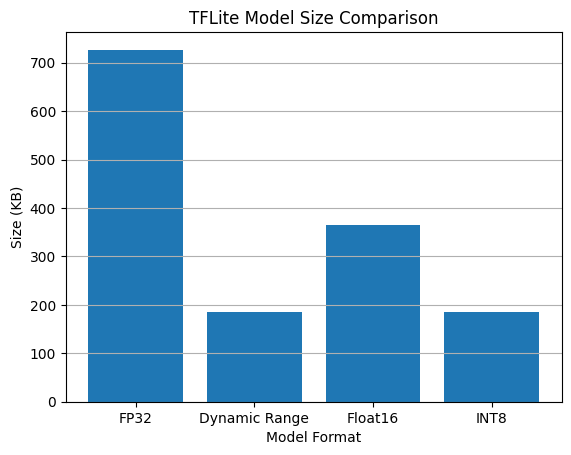

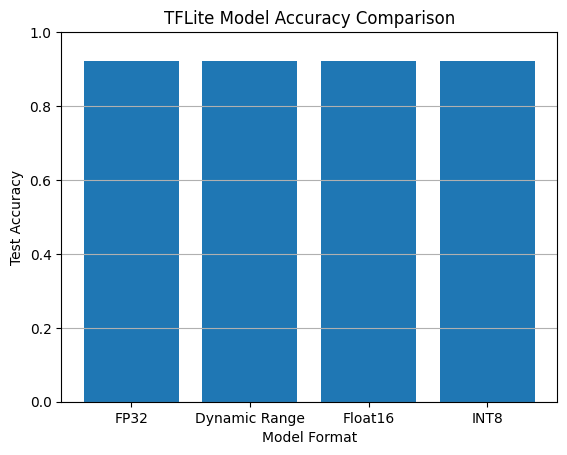

In [13]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#

plt.figure()
plt.bar(comparison_df["Format"], comparison_df["Model Size (KB)"])
plt.xlabel("Model Format")
plt.ylabel("Size (KB)")
plt.title("TFLite Model Size Comparison")
plt.grid(True, axis='y')
plt.show()

plt.figure()
plt.bar(comparison_df["Format"], comparison_df["Test Accuracy"])
plt.xlabel("Model Format")
plt.ylabel("Test Accuracy")
plt.title("TFLite Model Accuracy Comparison")
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.show()

### Confusion Matrix for the PTQ Int8 Model


Classification Report (INT8 PTQ):
                    precision    recall  f1-score   support

           WALKING       0.94      0.94      0.94       496
  WALKING_UPSTAIRS       0.95      0.89      0.92       471
WALKING_DOWNSTAIRS       0.89      0.96      0.92       420
           SITTING       0.98      0.80      0.88       491
          STANDING       0.81      0.98      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



<Figure size 800x800 with 0 Axes>

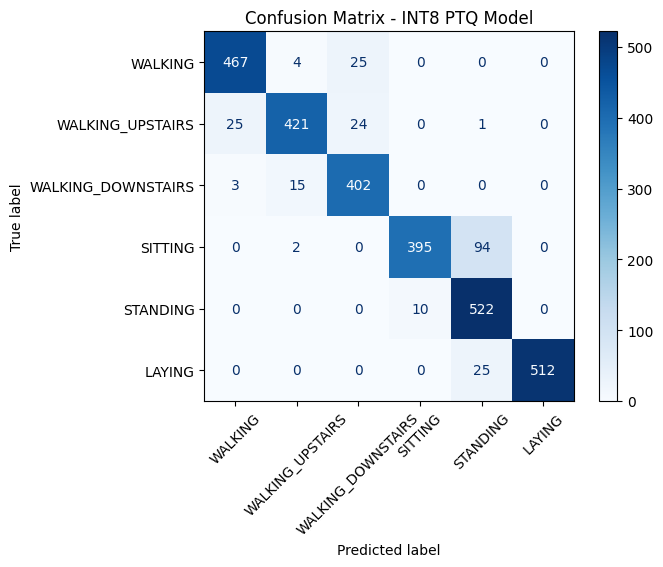

In [14]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#

_, y_pred_int8 = evaluate_tflite_model(tflite_int8, X_test, y_test)

print("Classification Report (INT8 PTQ):")
print(classification_report(y_test, y_pred_int8, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_int8)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(8, 8))
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix - INT8 PTQ Model")
plt.show()

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [15]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Fine-Tune the QAT Model


In [16]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
qat_history = qat_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/8
92/92 [==============================] - 3s 15ms/step - loss: 0.0453 - accuracy: 0.9850 - val_loss: 0.1297 - val_accuracy: 0.9449
Epoch 2/8
92/92 [==============================] - 1s 12ms/step - loss: 0.0365 - accuracy: 0.9888 - val_loss: 0.1328 - val_accuracy: 0.9483
Epoch 3/8
92/92 [==============================] - 1s 11ms/step - loss: 0.0363 - accuracy: 0.9874 - val_loss: 0.1416 - val_accuracy: 0.9477
Epoch 4/8
92/92 [==============================] - 1s 11ms/step - loss: 0.0327 - accuracy: 0.9884 - val_loss: 0.1319 - val_accuracy: 0.9456
Epoch 5/8
92/92 [==============================] - 1s 10ms/step - loss: 0.0318 - accuracy: 0.9893 - val_loss: 0.1688 - val_accuracy: 0.9422
Epoch 6/8
92/92 [==============================] - 1s 11ms/step - loss: 0.0316 - accuracy: 0.9884 - val_loss: 0.1545 - val_accuracy: 0.9463
Epoch 7/8
92/92 [==============================] - 1s 10ms/step - loss: 0.0315 - accuracy: 0.9895 - val_loss: 0.1364 - val_accuracy: 0.9483
Epoch 8/8
92/92 [===

### Evaluate the QAT Keras Model


In [17]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#
# Evaluate QAT model

test_loss, test_acc = qat_model.evaluate(X_test, y_test, verbose=0)

print("QAT Test Accuracy:", test_acc)

y_pred_qat = np.argmax(qat_model.predict(X_test), axis=1)

print("\nClassification Report (QAT):")
print(classification_report(y_test, y_pred_qat, target_names=class_names))

QAT Test Accuracy: 0.9321343898773193
93/93 [==============================] - 0s 4ms/step

Classification Report (QAT):
                    precision    recall  f1-score   support

           WALKING       0.92      0.97      0.95       496
  WALKING_UPSTAIRS       0.94      0.90      0.92       471
WALKING_DOWNSTAIRS       0.94      0.94      0.94       420
           SITTING       0.97      0.85      0.91       491
          STANDING       0.84      0.98      0.90       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [18]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#

converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_dataset_gen

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_qat = converter.convert()

size_qat = save_binary_model(tflite_qat, "model_qat_int8.tflite")
print("QAT INT8 Model Size (KB):", size_qat)

acc_qat_int8, y_pred_qat_int8 = evaluate_tflite_model(
    tflite_qat, X_test, y_test
)

print("QAT INT8 Test Accuracy:", acc_qat_int8)


INFO:tensorflow:Assets written to: /tmp/tmpmvv2fnux/assets


INFO:tensorflow:Assets written to: /tmp/tmpmvv2fnux/assets


QAT INT8 Model Size (KB): 185.6953125
QAT INT8 Test Accuracy: 0.9324737020699015


/home/mishrmuk/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-16 19:36:38.685388: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-16 19:36:38.685455: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-16 19:36:38.685646: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpmvv2fnux
2026-04-16 19:36:38.688809: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 19:36:38.688834: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpmvv2fnux
2026-04-16 19:36:38.701189: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-16 19:36:38.789699: I tensorflow/cc/saved_model/loa

## 12. PTQ Int8 vs QAT Int8


In [19]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
ptq_qat_df = pd.DataFrame({
    "Model": ["PTQ INT8", "QAT INT8"],
    "Test Accuracy": [acc_int8, acc_qat_int8],
    "Model Size (KB)": [size_int8, size_qat]
})

ptq_qat_df


,Model,Test Accuracy,Model Size (KB)
0,PTQ INT8,0.922633,185.335938
1,QAT INT8,0.932474,185.695312


<Figure size 800x800 with 0 Axes>

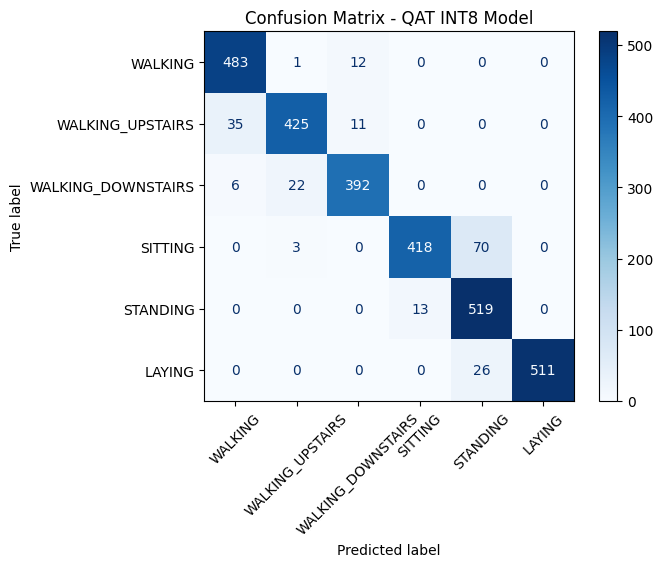

In [20]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
_, y_pred_qat_int8 = evaluate_tflite_model(tflite_qat, X_test, y_test)

cm_qat = confusion_matrix(y_test, y_pred_qat_int8)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_qat, display_labels=class_names)

plt.figure(figsize=(8, 8))
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix - QAT INT8 Model")
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
   INT8 (both PTQ and QAT) produced the smallest model size at around 185 KB). Dynamic range quantization was very similar, while FP32 was larger.
3. Which quantization method gave the best accuracy among the TensorFlow Lite models?
 QAT INT8 gave the best accuracy of 0.932) among the TFLite models, slightly outperforming PTQ INT8 and matching or slightly exceeding FP32 performance.
5. Did QAT improve the final int8 model compared with PTQ int8?
  QAT improved accuracy compared to PTQ INT8 at 0.932 versus 0.922 while keeping the model size essentially the same. 
7. Why is this dataset a good fit for a DNN-based TinyML workflow?
   The UCI HAR dataset is well-suited for a DNN-based TinyML approach because it has fixed-size numerical feature vectors. moderate dataset size with balanced classes, and clear separability between activity classes
9. If you were deploying this model on a resource-constrained device, which version would you choose and why?
I would choose the QAT INT8 model, because it provides the best tradeoff between performance and efficiency. It achieves the highest accuracy among quantized models while maintaining the smallest possible model size, making it ideal for deployment on memory- and compute-limited edge devices.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
